In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
import math
import random
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
### Initial basic scaled down test ###

tensor = torch.randint(low=0, high=6, size=(3, 8, 6), dtype=torch.int32).to(device).float()
tensor2 = torch.randint(low=0, high=6, size=(3, 8, 6), dtype=torch.int32).to(device).float()
print(tensor)
#print()
#print(tensor2)
tensor2[:, :7, :] = tensor[:, 1:, :]
print()
#tensor.zero_()

tensor[:, -1, :][:, -1] = -67
print(tensor)

#print(tensor.unsqueeze(1) @ tensor2)
#print(torch.cat(tensor.unbind(dim=1), dim=-1))
#print(tensor.sum(dim=3, keepdim=True) * tensor)

data = torch.zeros(8, 128).to(device)
#print(data)
data[0, 7] = 1
data[1, 6] = 1
data[2, 3] = 1
data[3, 5] = 1

data[4, 2] = 1
data[5, 1] = 1
data[6, 0] = 1
data[7, 4] = 1
#print()
#print(data)
#print()
data = data.repeat(4096, 1, 1)
#print(data.shape)
batch = 8
#print(data.shape[0] // batch)
#print(data[1:])

tensor([[[5., 5., 4., 0., 3., 2.],
         [5., 3., 3., 2., 4., 5.],
         [4., 1., 1., 5., 3., 2.],
         [2., 4., 3., 2., 2., 3.],
         [3., 3., 4., 2., 2., 1.],
         [0., 2., 1., 0., 5., 5.],
         [2., 1., 0., 5., 2., 0.],
         [4., 4., 3., 1., 5., 0.]],

        [[0., 5., 3., 5., 0., 2.],
         [0., 0., 2., 0., 5., 2.],
         [2., 1., 5., 0., 5., 2.],
         [3., 1., 1., 5., 0., 0.],
         [0., 1., 2., 3., 1., 3.],
         [4., 0., 0., 4., 0., 1.],
         [3., 0., 0., 5., 1., 2.],
         [4., 3., 3., 5., 0., 2.]],

        [[5., 2., 5., 1., 1., 2.],
         [4., 2., 4., 5., 2., 5.],
         [1., 5., 1., 3., 0., 0.],
         [2., 4., 0., 5., 5., 0.],
         [5., 4., 1., 1., 1., 3.],
         [1., 4., 0., 3., 0., 5.],
         [2., 3., 4., 0., 2., 3.],
         [4., 1., 1., 4., 3., 1.]]], device='cuda:0')

tensor([[[  5.,   5.,   4.,   0.,   3.,   2.],
         [  5.,   3.,   3.,   2.,   4.,   5.],
         [  4.,   1.,   1.,   5.,   3.,   

In [3]:
### inputting a few sentences over and over to see if the model can memorize them ###

words = [
    "a",
    "and",
    "apples",
    "at",
    "big",
    "birds",
    "bloom",
    "blue",
    "boat",
    "books",
    "bright",
    "brown",
    "car",
    "cats",
    "children",
    "clouds",
    "coffee",
    "cold",
    "dance",
    "deep",
    "dog",
    "down",
    "falls",
    "fast",
    "fish",
    "floats",
    "flowers",
    "fly",
    "frog",
    "from",
    "games",
    "goes",
    "good",
    "great",
    "green",
    "grow",
    "high",
    "hot",
    "i",
    "in",
    "is",
    "lake",
    "like",
    "makes",
    "me",
    "music",
    "new",
    "night",
    "old",
    "on",
    "park",
    "people",
    "play",
    "ran",
    "red",
    "see",
    "shine",
    "sky",
    "sleep",
    "slow",
    "small",
    "snow",
    "spring",
    "stars",
    "stories",
    "sun",
    "swim",
    "tell",
    "the",
    "time",
    "tiny",
    "to",
    "trees",
    "up",
    "us",
    "very",
    "wakes",
    "want",
    "water",
    "yellow"
]
sentences = [
    "the big brown dog ran fast",
    "cats like to sleep in the sun",
    "birds fly high in the blue sky",
    "red apples grow on green trees",
    "i see a tiny green frog",
    "water is cold and very good",
    "the old car goes very slow",
    "children play games in the park",
    "fish swim deep in the lake",
    "stars shine bright at night time",
    "yellow flowers bloom in the spring",
    "snow falls down from cold clouds",
    "books tell us great new stories",
    "music makes people want to dance",
    "hot coffee wakes me up fast",
    "the small boat floats on water",
]
#print(sentences)
indicies_ = []
temp = []
for i in sentences:
    for j in i.split():
        temp.append(words.index(j))
    indicies_.append(temp)
    temp = []


for i in indicies_:
    if len(i) == 6:
        i.append(127)
        i.append(126)
    else:
        i.append(127)


tensor_list = []

for i in indicies_:
    tensor_list.append( F.one_hot(torch.tensor(i, dtype=torch.long), num_classes=128) )

#print(tensor_list)
data = torch.stack(tensor_list, dim=0)
data = data.float().to(device)
print(data.device)

cuda:0


In [4]:
### Functions for proecessing data into inputtable tokens ###

from __future__ import annotations
import argparse
import random
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple
import json

import numpy as np
import matplotlib.pyplot as plt

# Global Constants
END_PUNCT = {".", "!", "?"}
#DEFAULT_BOOK = Path(__file__).with_name("AliceinWonderland.txt")
MAX_NUM_OF_WORDS_IN_A_SENTENCE = 1500

# Utility functions to load the data """
def load_book(path: Path) -> str:
    """
    - To Read raw text from the local file (AliceinWonderland.txt)
    - Do not edit this function for pe2.
    """
    data = path.read_text(encoding="utf-8", errors="ignore")
    return strip_gutenberg_header_footer(data)

def strip_gutenberg_header_footer(text: str) -> str:
    """
    - To strip header/footer and extract contents of the book.
    - Do not edit this function for pe2.
    """
    start_pat = re.compile(r"\*\*\*\s*START OF (THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*", re.I | re.S)
    end_pat   = re.compile(r"\*\*\*\s*END OF (THIS|THE) PROJECT GUTENBERG EBOOK.*?\*\*\*", re.I | re.S)
    start = start_pat.search(text)
    end = end_pat.search(text)
    if start and end and start.end() < end.start():
        return text[start.end():end.start()]
    return text
    
def tokenize(text: str) -> List[str]:
    """
    - tokenizer
    - The tokens returned includes ending punctuations '.' ',' and '!' 
    - Do not edit this function for pe2.
    """
    pattern = (
        r"(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?"   # captures abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"   # captures words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"                 # captures END_PUNCT only at end of a word
    )
    return [t.lower() for t in re.findall(pattern, text)] 

def freq_of_words(tokens: List[str]) -> Dict[str, int]:
    """
    - Return {token: frequency} for all tokens.
    - Do not edit this function for pe2.
    """
    freqs: Dict[str, int] = {}
    for t in tokens:
        if t in freqs:
            freqs[t] += 1
        else:
            freqs[t] = 1
    return freqs

In [2]:
path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-train.txt"
DEFAULT_BOOK = Path(path)
print("got the path")
data = DEFAULT_BOOK.read_text(encoding="utf-8", errors="ignore")
print("got the data")
tokens_all = tokenize(data)
print("tokenized it")
tokens_count_train = freq_of_words(tokens_all)

got the path
got the data
tokenized it


In [7]:
print(len(tokens_count_train))
filehandler = open("TokenCountsTraining.txt", 'wt')
print("filehandler worked")
data = str(tokens_count_train)
filehandler.write(data)

42656
filehandler worked


635869

In [4]:
path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-valid.txt"
DEFAULT_BOOK = Path(path)
print("got the path")
data = DEFAULT_BOOK.read_text(encoding="utf-8", errors="ignore")
print("got the data")
tokens_all = tokenize(data)
print("tokenized it")
tokens_count_validation = freq_of_words(tokens_all)

got the path
got the data
tokenized it


In [8]:
print(len(tokens_count_validation))
filehandler = open("TokenCountsValidation.txt", 'wt')
print("filehandler worked")
data = str(tokens_count_validation)
filehandler.write(data)

10516
filehandler worked


149472

In [19]:
path = "/home/aditya/Downloads/validation.jsonl"
DEFAULT_BOOK = Path(path)
print("got the path")
data = DEFAULT_BOOK.read_text(encoding="utf-8", errors="ignore")
print("got the data")
tokens_all = tokenize(data)
print("tokenized it")
tokens_count_brainrot_validation = freq_of_words(tokens_all)

got the path
got the data
tokenized it


In [20]:
print(len(tokens_count_brainrot_validation))
filehandler = open("TokenCountsBrainrotValidation.txt", 'wt')
print("filehandler worked")
data = str(tokens_count_brainrot_validation)
filehandler.write(data)

889
filehandler worked


11535

In [21]:
path = "/home/aditya/Downloads/test.jsonl"
DEFAULT_BOOK = Path(path)
print("got the path")
data = DEFAULT_BOOK.read_text(encoding="utf-8", errors="ignore")
print("got the data")
tokens_all = tokenize(data)
print("tokenized it")
tokens_count_brainrot_test = freq_of_words(tokens_all)

got the path
got the data
tokenized it


In [22]:
print(len(tokens_count_brainrot_test))
filehandler = open("TokenCountsBrainrotTest.txt", 'wt')
print("filehandler worked")
data = str(tokens_count_brainrot_test)
filehandler.write(data)

1295
filehandler worked


16979

In [23]:
path = "/home/aditya/Downloads/train.jsonl"
DEFAULT_BOOK = Path(path)
print("got the path")
data = DEFAULT_BOOK.read_text(encoding="utf-8", errors="ignore")
print("got the data")
tokens_all = tokenize(data)
print("tokenized it")
tokens_count_brainrot_train = freq_of_words(tokens_all)

got the path
got the data
tokenized it


In [24]:
print(len(tokens_count_brainrot_train))
filehandler = open("TokenCountsBrainrotTrain.txt", 'wt')
print("filehandler worked")
data = str(tokens_count_brainrot_train)
filehandler.write(data)

8555
filehandler worked


121794

In [2]:
### Compiling Vocabulary ###


dict_list = [tokens_count_train, tokens_count_validation, tokens_count_brainrot_validation, tokens_count_brainrot_test, tokens_count_brainrot_train]
combined = sum((Counter(d) for d in dict_list), Counter())
result = dict(combined)
#print(result)

vocabulary = list(result.keys())
vocabulary = sorted(vocabulary)


NameError: name 'tokens_count_train' is not defined

In [5]:
### Finalizing Vocabulary ###

import json

vocabulary = []

with open('vocab_copy.json', 'r') as file:
    vocabulary = json.load(file)

vocabulary.append("<|endoftext|>")
vocabulary.append("<unk>")
vocabulary.append("<pad>")

print(vocabulary[0:10])

['!', '.', '?', 'a', "a's", 'a.b.', 'a.m.', 'aa', 'aaa', 'aaaaaa']


In [6]:
import json
import re
from typing import List, Set, Generator, Iterable

def stream_vocab_batches(
    file_path: str,
    vocab: Iterable[str],
    batch: int,
    T: int,
    text_key: str = "text",
    unk_token: str = "<unk>"
) -> Generator[List[List[str]], None, None]:
    """
    Streams tokens from a JSON/JSONL file using a custom regex tokenizer,
    replaces out-of-vocabulary tokens with `unk_token`, and yields them 
    in batches of shape [batch, T].

    :param file_path: Path to the JSON or JSONL file.
    :param vocab: Iterable of valid vocabulary strings.
    :param batch: Number of sequences per batch (outer list length).
    :param T: Number of tokens per sequence (inner list length).
    :param text_key: JSON key containing the text string.
    :param unk_token: Replacement string for tokens not in `vocab`.
    :return: Yields List[List[str]] of shape [batch, T].
    """
    # 1. Convert vocab to a set for O(1) constant time lookups
    vocab_set: Set[str] = set(vocab)

    # 2. Replicate your EXACT tokenizer pattern
    pattern = (
        r"(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?"   # Abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"   # Words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"                 # End punctuation directly after a word
    )

    current_sequence: List[str] = []
    accumulated_batch: List[List[str]] = []

    # 3. Read file line-by-line (JSONL)
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            record = json.loads(line)
            text = record.get(text_key, "")

            # Apply your exact tokenization & lowercasing logic
            tokens = [t.lower() for t in re.findall(pattern, text)]

            for token in tokens:
                # O(1) Vocabulary Lookup
                processed_token = token if token in vocab_set else unk_token
                current_sequence.append(processed_token)

                # Once sequence length reaches T
                if len(current_sequence) == T:
                    accumulated_batch.append(current_sequence)
                    current_sequence = []

                    # Once we have accumulated 'batch' sequences of length T
                    if len(accumulated_batch) == batch:
                        yield accumulated_batch
                        accumulated_batch = []

    # Optional: Yield remaining full/partial batch data at the end of the file
    if current_sequence:
        accumulated_batch.append(current_sequence)
    if accumulated_batch:
        yield accumulated_batch

In [7]:
import torch
import re
from typing import List, Set, Dict, Tuple, Generator, Iterable

def stream_text_vocab_batches(
    file_path: str,
    vocab: Iterable[str],
    batch: int,
    T: int,
    unk_token: str = "<unk>"
) -> Generator[Tuple[torch.Tensor, torch.Tensor], None, None]:
    """
    Streams tokens from a plain .txt file using custom regex tokenization,
    replaces out-of-vocabulary tokens with `unk_token`, and yields them 
    in batches of shape [batch, T].

    :param file_path: Path to the plain text (.txt) file.
    :param vocab: Iterable of valid vocabulary strings.
    :param batch: Number of sequences per batch.
    :param T: Context window length per sequence.
    :param unk_token: Replacement string for tokens not in `vocab`.
    :return: Yields tuples of (input_tensor, target_tensor) both of shape [batch, T].
    """
    # Convert vocab into a set for checking and a mapping dict for fast indexing
    vocab_list: List[str] = list(vocab)
    vocab_set: Set[str] = set(vocab_list)
    token_to_id: Dict[str, int] = {token: idx for idx, token in enumerate(vocab_list)}
    
    # Pre-calculate unk_token ID
    unk_id: int = token_to_id.get(unk_token, 0)

    # Regex pattern
    pattern = (
        r"<\|endoftext\|>"                    # Captures <|endoftext|> intact
        r"|(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?" # Captures abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"   # Captures words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"                 # Captures punctuation at the end of a word
    )

    current_sequence: List[int] = []
    accumulated_data: List[List[int]] = []
    accumulated_answers: List[List[int]] = []

    # Read plain text file line-by-line
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Tokenize plain text line
            raw_tokens = re.findall(pattern, line)

            for token in raw_tokens:
                # Retain case for special tokens, lowercase regular words
                processed_token = token if token == "<|endoftext|>" else token.lower()

                # Fast token lookup
                token_id = token_to_id.get(processed_token, unk_id)
                current_sequence.append(token_id)

                # Build sequences of length T (requires T + 1 tokens for input + target)
                if len(current_sequence) == T + 1:
                    accumulated_data.append(current_sequence[:-1])
                    accumulated_answers.append(current_sequence[1:])
                    
                    # Carry over the last token so sequence context remains continuous
                    current_sequence = current_sequence[-1:]

                    # Yield once we have enough sequences for a batch
                    if len(accumulated_data) == batch:
                        yield torch.tensor(accumulated_data, dtype=torch.long), torch.tensor(accumulated_answers, dtype=torch.long)
                        accumulated_data = []
                        accumulated_answers = []
                        
# Testing if it works
for i, batch_data in enumerate(stream_text_vocab_batches("/home/aditya/Downloads/TinyStoriesV2-GPT4-train.txt", vocabulary, batch=32, T=512)):
    # batch_data is shape [32, 512]
    print(batch_data[0])
    print()
    print(batch_data[1].shape)
    if i < 2:
        break
    #print(i)
    #pass

tensor([[26217, 41615,     3,  ...,     0, 42863, 10420],
        [42618, 10420, 43428,  ..., 18341, 24940,  3986],
        [ 1190, 18026, 43225,  ..., 25734, 16844, 18996],
        ...,
        [38896, 42810, 10555,  ..., 16570,  1190, 36562],
        [39497,  9099,     1,  ..., 21757, 15174, 29763],
        [26213, 17077, 25396,  ..., 38690,  5256,  8425]])

torch.Size([32, 512])


In [8]:
### Creating Validation Dataset ###

layers = 8
v = len(vocabulary)
T = 256
d = 512
h = 8
batch = 16

path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-valid.txt"

valid_all_data = []

for j, batch_data in tqdm(enumerate(stream_text_vocab_batches(path, vocabulary, batch, T))):
    valid_all_data.append(batch_data)
    
#valid_data_tensor = torch.cat(valid_data_list, dim=0).to(device)
#valid_answers_tensor = torch.cat(valid_answers_list, dim=0).to(device)

#valid_data_tensor = valid_data_tensor[:512]
#valid_answers_tensor = valid_answers_tensor[:512]




1204it [00:02, 508.35it/s]


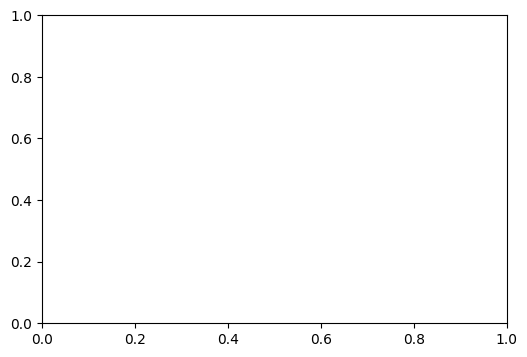

In [9]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

In [10]:
### Forward Pass Functions ###

def encoding_matrix_generator(T, d, device):
    pe = torch.zeros(T, d).to(device)
    position = torch.arange(0, T, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe.unsqueeze(0)

def RMS_Norm(gamma, X, d, epsilon):
    return gamma * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) )

def A(X, W_k, W_q, T, d, h, mask):
    return torch.softmax( ( ((X@W_q) @ (X@W_k).mT) / ((d/h)**0.5) ).masked_fill(mask==0, float('-inf')) , dim=-1 )

def MHA(X, A, W_v, W_o):
    return (A @ (X@W_v) @ W_o).sum(dim=-3) #### was org dim=1

def MLP(X, W_1, b_1, W_2, b_2):
    return F.leaky_relu((X@W_1 + b_1.unsqueeze(0)), negative_slope=0.01)@W_2 + b_2.unsqueeze(0)

In [11]:
### Cosine Decay Function ###

def get_cosine_with_warmup_lr(current_step, max_lr, min_lr, warmup_steps, total_steps):
    """
    Calculates the learning rate (eta) for a given training step using
    linear warmup followed by sinusoidal cosine decay.
    """
    # Safety check: if we somehow overshoot total steps, return min_lr
    if current_step >= total_steps:
        return min_lr

    # PHASE 1: Linear Warmup
    if current_step < warmup_steps:
        # Avoid division by zero if warmup_steps is set to 0
        if warmup_steps == 0:
            return max_lr
        # Linearly ramp up from 0 to max_lr
        return max_lr * (current_step / warmup_steps)
        
    # PHASE 2: Cosine Decay
    else:
        # Calculate progress through the decay phase
        decay_steps = total_steps - warmup_steps
        current_decay_step = current_step - warmup_steps
        
        # Determine progress fraction from 0.0 to 1.0
        progress = current_decay_step / decay_steps
        
        # Apply the cosine formula
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        
        # Scale the decay between min_lr and max_lr
        return min_lr + (max_lr - min_lr) * cosine_decay


In [12]:
### Backpropagation Functions ###

def Norm_gradient(X, epsilon, delta, batch, T, d):
    return ( delta * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) ) ).sum(dim=0).sum(dim=0) / batch / T

def Norm_X_gradient(X, gamma, epsilon, delta, d):
    return (( (gamma * delta) - 
            1/d * (X / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon) ) * 
            (RMS_Norm(gamma, X, d, epsilon) * delta).sum(dim=-1, keepdim=True) ) / torch.sqrt(1/d * (X*X).sum(dim=-1, keepdim=True) + epsilon))
    
def W_o_gradient(A, X, W_v, delta, batch, d, h):
    return ( ((torch.cat( ( A @ (X@W_v) ).unbind(1), dim=-1 )).mT @ delta).sum(dim=0) / batch ).view(h, d//h, d)
  
def W_v_gradient(A, X, delta, W_o, batch):
    return (X.mT @ A.mT @ delta @ W_o.mT).sum(dim=0) / batch

def W_q_gradient(A, X, delta, W_o, W_v, W_k, d, h, batch):
    return (X.mT @ (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ (X@W_k) / ((d/h)**0.5)).sum(dim=0) / batch

def W_k_gradient(A, X, delta, W_o, W_v, W_q, d, h, batch):
    return (( (X@W_q).mT @ (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ X ).mT / ((d/h)**0.5)).sum(dim=0) / batch

def X_gradient(A, X, delta, W_o, W_v, W_k, W_q, d, h):
    return (
           (A.mT @ delta @ W_o.mT @ W_v.mT)
           + (1/((d/h)**0.5)) * (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ) @ (X@W_k) @ W_q.mT
           + (1/((d/h)**0.5)) * (A * ( (delta @ W_o.mT @ (X@W_v).mT) - (A*(delta @ W_o.mT @ (X@W_v).mT)).sum(dim=-1, keepdim=True) ) ).mT @ (X@W_q) @ W_k.mT 
           ).sum(dim=1)

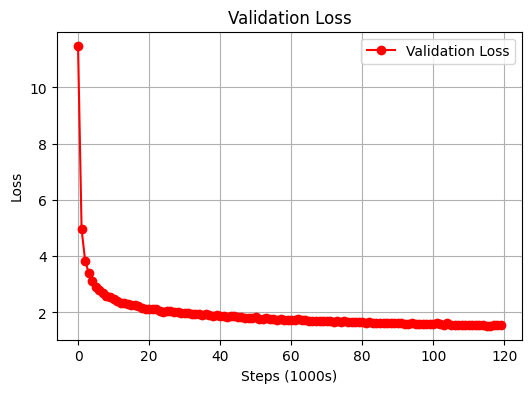

119265it [31:41:23,  1.05it/s]


[11.541335105895996, 11.48901653289795, 11.498079299926758, 11.497943878173828, 11.485478401184082, 11.465385437011719, 11.4680814743042, 11.424772262573242, 11.345318794250488, 11.329479217529297, 11.337568283081055, 11.365585327148438, 11.284879684448242, 11.215863227844238, 11.188079833984375, 11.112256050109863, 11.075207710266113, 11.027881622314453, 10.992992401123047, 10.905355453491211, 10.82723617553711, 10.753024101257324, 10.74668025970459, 10.628559112548828, 10.573164939880371, 10.44912052154541, 10.420842170715332, 10.296344757080078, 10.261605262756348, 10.20211410522461, 10.12264633178711, 10.031972885131836, 9.910225868225098, 9.924607276916504, 9.833131790161133, 9.768942832946777, 9.686612129211426, 9.56952953338623, 9.61461067199707, 9.569289207458496, 9.470306396484375, 9.423047065734863, 9.322123527526855, 9.370424270629883, 9.353276252746582, 9.272285461425781, 9.196731567382812, 9.164713859558105, 9.248655319213867, 9.106199264526367, 9.063270568847656, 9.028701

In [36]:
### Algorithm Implementation ###
"""
layers = 8
v = len(vocabulary)
T = 256
d = 512
h = 8
batch = 16
"""
k = 1.0
beta_1 = 0.9
beta_2 = 0.999
eta = 12.0
eta_max = 3e-4
eta_min = 3e-5
warmup_steps = 1450
total_steps = 145000
lmbda = 0.1 #0.05
epsilon = 1e-8

path = "/home/aditya/Downloads/TinyStoriesV2-GPT4-train.txt"

#one_hot_vecs = torch.zeros(batch, T, v).to(device)
#actual = torch.zeros(batch, T, v).to(device)
embedding_matrix = torch.randn(v, d).to(device) * (1.0 / (d ** 0.5))
encoding_matrix = encoding_matrix_generator(T, d, device)
X_EmbEnc = torch.zeros(batch, T, d).to(device)

mask = torch.tril(torch.ones(T, T, device=device))

W_q = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_k = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_v = torch.randn(layers, h, d, d//h).to(device) * (2.0 / (d + d//h))**0.5
W_o = torch.randn(layers, h, d//h, d).to(device) * (2.0 / (d + d//h))**0.5
X_postMHA = torch.zeros(layers, batch, T, d).to(device)
gamma_MHA = torch.ones(layers, d).to(device)

W_1 = torch.randn(layers, d, 4*d).to(device) * (2.0 / d)**0.5
b_1 = torch.zeros(layers, 4*d).to(device)
W_2 = torch.randn(layers, 4*d, d).to(device) * (2.0 / (4*d))**0.5
b_2 = torch.zeros(layers, d).to(device)
X_postMLP = torch.zeros(layers, batch, T, d).to(device)
gamma_MLP = torch.ones(layers, d).to(device)

gamma_out = torch.ones(d,).to(device)
results = torch.rand(batch, T, v).to(device)
loss = []


#embedding_matrix_save = embedding_matrix.clone()
W_q_save = W_q.clone()
W_k_save = W_k.clone()
W_v_save = W_v.clone()
W_o_save = W_o.clone()
gamma_MHA_save = gamma_MHA.clone()
gamma_MLP_save = gamma_MLP.clone()
gamma_out_save = gamma_out.clone()
W_1_save = W_1.clone()
b_1_save = b_1.clone()
W_2_save = W_2.clone()
b_2_save = b_2.clone()

### Gradient Descent Matricies ###
embedding_matrix_velo = torch.zeros(v, d).to(device)
embedding_matrix_sum = torch.zeros(v, d).to(device)
embedding_matrix_grad = torch.zeros(v, d).to(device)

W_q_velo = torch.zeros(layers, h, d, d//h).to(device)
W_q_sum = torch.zeros(layers, h, d, d//h).to(device)
W_q_grad = torch.zeros(layers, h, d, d//h).to(device)

W_k_velo = torch.zeros(layers, h, d, d//h).to(device)
W_k_sum = torch.zeros(layers, h, d, d//h).to(device)
W_k_grad = torch.zeros(layers, h, d, d//h).to(device)

W_v_velo = torch.zeros(layers, h, d, d//h).to(device)
W_v_sum = torch.zeros(layers, h, d, d//h).to(device)
W_v_grad = torch.zeros(layers, h, d, d//h).to(device)

W_o_velo = torch.zeros(layers, h, d//h, d).to(device)
W_o_sum = torch.zeros(layers, h, d//h, d).to(device)
W_o_grad = torch.zeros(layers, h, d//h, d).to(device)

gamma_MHA_velo = torch.zeros(layers, d).to(device)
gamma_MHA_sum = torch.zeros(layers, d).to(device)
gamma_MHA_grad = torch.zeros(layers, d).to(device)

W_1_velo = torch.zeros(layers, d, 4*d).to(device)
W_1_sum = torch.zeros(layers, d, 4*d).to(device)
W_1_grad = torch.zeros(layers, d, 4*d).to(device)

b_1_velo = torch.zeros(layers, 4*d).to(device)
b_1_sum = torch.zeros(layers, 4*d).to(device)
b_1_grad = torch.zeros(layers, 4*d).to(device)

W_2_velo = torch.zeros(layers, 4*d, d).to(device)
W_2_sum = torch.zeros(layers, 4*d, d).to(device)
W_2_grad = torch.zeros(layers, 4*d, d).to(device)

b_2_velo = torch.zeros(layers, d).to(device)
b_2_sum = torch.zeros(layers, d).to(device)
b_2_grad = torch.zeros(layers, d).to(device)

gamma_MLP_velo = torch.zeros(layers, d).to(device)
gamma_MLP_sum = torch.zeros(layers, d).to(device)
gamma_MLP_grad = torch.zeros(layers, d).to(device)

gamma_out_velo = torch.zeros(d,).to(device)
gamma_out_sum = torch.zeros(d,).to(device)
gamma_out_grad = torch.zeros(d,).to(device)

delta = torch.zeros(batch, T, d).to(device)
delta_temp = torch.zeros(batch, T, d).to(device)
#final_one_hot_vecs_mult = torch.zeros(batch, v, d).to(device)

valid_data_indicies = torch.zeros(batch, T).to(device)
valid_answer_indicies = torch.zeros(batch, T).to(device)
batch_loss_store = []
valid_loss = []
steps = []



for j, batch_data in tqdm(enumerate(stream_text_vocab_batches(path, vocabulary, batch, T))): 
    
    embedding_matrix_grad.zero_()
    W_q_grad.zero_()
    W_k_grad.zero_()
    W_v_grad.zero_()
    W_o_grad.zero_()
    gamma_MHA_grad.zero_()
    W_1_grad.zero_()
    b_1_grad.zero_()
    W_2_grad.zero_()
    b_2_grad.zero_()
    gamma_MLP_grad.zero_()
    gamma_out_grad.zero_()

    eta = get_cosine_with_warmup_lr(j, eta_max, eta_min, warmup_steps, total_steps)
    
    """
    Embedding and Encoding
    """
    data_indicies = batch_data[0].to(device)
    answer_indicies = batch_data[1].to(device)

    X_EmbEnc = F.embedding(data_indicies, embedding_matrix) + encoding_matrix
    """
    Transformer Layers
    """
    for i in range(layers):
        if i == 0:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_EmbEnc
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
        else:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_postMLP[i-1]
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]

    """
    Decoding
    """
    results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
    loss.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                 answer_indicies.view(-1)).item()) 

    """
    BACKPROPAGATION
    """
    """
    Decoding Backprop
    """
    results[torch.arange(batch).unsqueeze(1), torch.arange(T).unsqueeze(0), answer_indicies] -= 1     # results - actual
 
    embedding_matrix_grad = (( RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon).mT @ (results) ).mT).sum(dim=0) / batch / T ###
    delta = ( (results) @ embedding_matrix ) / T
    
    gamma_out_grad = Norm_gradient(X_postMLP[layers-1], epsilon, delta, batch, T, d)
    gamma_out_velo = beta_1 * gamma_out_velo + (1-beta_1) * gamma_out_grad 
    gamma_out_sum = beta_2 * gamma_out_sum + (1-beta_2) * gamma_out_grad.square()
    
    delta = Norm_X_gradient(X_postMLP[layers-1], gamma_out, epsilon, ( (results) @ embedding_matrix ), d) 
    """
    Transformer Backprop
    """
    for i in reversed(range(layers)):
        W_2_grad[i] = (( F.leaky_relu( (RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                                     negative_slope=0.01) ).mT @ delta).sum(dim=0) / batch
        W_2_velo[i] = beta_1 * W_2_velo[i] + (1-beta_1) * W_2_grad[i]
        W_2_sum[i] = beta_2 * W_2_sum[i] + (1-beta_2) * W_2_grad[i].square()

        b_2_grad[i] = (delta.sum(dim=-2)).sum(dim=0) / batch
        b_2_velo[i] = beta_1 * b_2_velo[i] + (1-beta_1) * b_2_grad[i]
        b_2_sum[i] = beta_2 * b_2_sum[i] + (1-beta_2) * b_2_grad[i].square()

        delta_temp = ((delta @ W_2[i].mT) * 
                ( ( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) >= 0 ).float() 
                + 0.01*( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) < 0 ) ))
     
        W_1_grad[i] = ((RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon)).mT @ delta_temp).sum(dim=0) / batch
        W_1_velo[i] = beta_1 * W_1_velo[i] + (1-beta_1) * W_1_grad[i]
        W_1_sum[i] = beta_2 * W_1_sum[i] + (1-beta_2) * W_1_grad[i].square()

        b_1_grad[i] = (delta_temp.sum(dim=-2)).sum(dim=0) / batch
        b_1_velo[i] = beta_1 * b_1_velo[i] + (1-beta_1) * b_1_grad[i]
        b_1_sum[i] = beta_2 * b_1_sum[i] + (1-beta_2) * b_1_grad[i].square()

        delta_temp = delta_temp @ W_1[i].mT

        gamma_MLP_grad[i] = Norm_gradient(X_postMHA[i], epsilon, delta_temp, batch, T, d)
        gamma_MLP_velo[i] = beta_1 * gamma_MLP_velo[i] + (1-beta_1) * gamma_MLP_grad[i]
        gamma_MLP_sum[i] = beta_2 * gamma_MLP_sum[i] + (1-beta_2) * gamma_MLP_grad[i].square()

        delta = Norm_X_gradient(X_postMHA[i], gamma_MLP[i], epsilon, delta_temp, d) + delta

        if i==0:
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_EmbEnc, epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_EmbEnc, gamma_MHA[i], epsilon, delta_temp, d) + delta
        else:    
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_postMLP[i-1], epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_postMLP[i-1], gamma_MHA[i], epsilon, delta_temp, d) + delta

        
        W_2[i] = (W_2[i] 
                 - eta / ( epsilon + (W_2_sum[i] / (1-beta_2**k)).sqrt() ) * (W_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_2[i])

        b_2[i] = (b_2[i] 
                 - eta / ( epsilon + (b_2_sum[i] / (1-beta_2**k)).sqrt() ) * (b_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_2[i])

        W_1[i] = (W_1[i] 
                 - eta / ( epsilon + (W_1_sum[i] / (1-beta_2**k)).sqrt() ) * (W_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_1[i])

        b_1[i] = (b_1[i] 
                 - eta / ( epsilon + (b_1_sum[i] / (1-beta_2**k)).sqrt() ) * (b_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_1[i])

        gamma_MLP[i] = (gamma_MLP[i] 
                 - eta / ( epsilon + (gamma_MLP_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MLP_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MLP[i])
        
        W_o[i] = (W_o[i] 
                 - eta / ( epsilon + (W_o_sum[i] / (1-beta_2**k)).sqrt() ) * (W_o_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_o[i])

        W_v[i] = (W_v[i] 
                 - eta / ( epsilon + (W_v_sum[i] / (1-beta_2**k)).sqrt() ) * (W_v_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_v[i])
        
        W_k[i] = (W_k[i] 
                 - eta / ( epsilon + (W_k_sum[i] / (1-beta_2**k)).sqrt() ) * (W_k_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_k[i])
        
        W_q[i] = (W_q[i] 
                 - eta / ( epsilon + (W_q_sum[i] / (1-beta_2**k)).sqrt() ) * (W_q_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_q[i])

        gamma_MHA[i] = (gamma_MHA[i] 
                 - eta / ( epsilon + (gamma_MHA_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MHA_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MHA[i])


    # embedding_matrix + one_hot_vecs.mT @ delta
    embedding_matrix_grad = (embedding_matrix_grad.index_add_(dim=0, index=data_indicies.reshape(-1), source=delta.reshape(-1, d)))/batch 
    embedding_matrix_velo = beta_1 * embedding_matrix_velo + (1-beta_1) * embedding_matrix_grad
    embedding_matrix_sum = beta_2 * embedding_matrix_sum + (1-beta_2) * embedding_matrix_grad.square()
    embedding_matrix = (embedding_matrix 
                 - eta / ( epsilon + (embedding_matrix_sum / (1-beta_2**k)).sqrt() ) * (embedding_matrix_velo / (1-beta_1**k))
                 - eta * lmbda * embedding_matrix)
    
    gamma_out = (gamma_out 
                 - eta / ( epsilon + (gamma_out_sum / (1-beta_2**k)).sqrt() ) * (gamma_out_velo / (1-beta_1**k))
                 - eta * lmbda * gamma_out)
    
    
    """
    Validate Every 1000 Batches
    """
    if j%1000 == 0:
        for data_point in random.sample(valid_all_data, 50):

            valid_data_indicies = data_point[0].to(device)
            valid_answer_indicies = data_point[1].to(device)
            
            X_EmbEnc = F.embedding(valid_data_indicies, embedding_matrix) + encoding_matrix
            
            """
            Transformer Layers
            """
            for i in range(layers):
                if i == 0:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_EmbEnc
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
                else:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_postMLP[i-1]
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
            
            """
            Decoding
            """
            results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
            batch_loss_store.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                         valid_answer_indicies.view(-1)).item())

        valid_loss.append( sum(batch_loss_store) / len(batch_loss_store) )
        steps.append(j/1000)

        # Clear the old output ONLY when the new plot is ready to render
        clear_output(wait=True)
    
        # Wipe the old line from the axis, but keep the window size intact
        ax.cla()
    
        # Redraw the updated data line
        ax.plot(steps, valid_loss, "r-", marker="o", label="Validation Loss")
        ax.set_title("Validation Loss")
        ax.set_xlabel("Steps (1000s)")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()
    
        # Instantly push the updated figure to the screen
        display(fig)
        
        batch_loss_store = []
    
    k = k+1


print(loss)
print(valid_loss)

Weight_Tensors = { "embedding_matrix" : embedding_matrix,
                   "W_q" : W_q,
                   "W_k" : W_k,
                   "W_v" : W_v,
                   "W_o" : W_o,
                   "gamma_MHA" : gamma_MHA,
                   "W_1" : W_1,
                   "b_1" : b_1,
                   "W_2" : W_2,
                   "b_2" : b_2,
                   "gamma_MLP" : gamma_MLP,
                   "gamma_out" : gamma_out }

torch.save(Weight_Tensors, "LLM_Weights.pt")

In [23]:
Weight_Tensors = { "embedding_matrix" : embedding_matrix,
                   "W_q" : W_q,
                   "W_k" : W_k,
                   "W_v" : W_v,
                   "W_o" : W_o,
                   "gamma_MHA" : gamma_MHA,
                   "W_1" : W_1,
                   "b_1" : b_1,
                   "W_2" : W_2,
                   "b_2" : b_2,
                   "gamma_MLP" : gamma_MLP,
                   "gamma_out" : gamma_out }

torch.save(Weight_Tensors, "LLM_Weights.pt")

In [196]:
X_infer_EmbEnc = torch.zeros(T, d).to(device)
X_infer_postMHA = torch.zeros(layers, T, d).to(device)
X_infer_postMLP = torch.zeros(layers, T, d).to(device)

# Getting input and indicies
sentence_input = """Once upon a time there was a little boy named Ben. Ben loved to explore the world around him. He saw many amazing things, like beautiful vases that were on display in a store. One day, Ben was walking through the store when he came across a very special vase. When Ben saw it he was amazed!  
He said, “Wow, that is a really amazing vase! Can I buy it?” 
The shopkeeper smiled and said, “Of course you can. You can take it home and show all your friends how amazing it is!”
So Ben took the vase home and he was so proud of it! He called his friends over and showed them the amazing vase. All his friends thought the vase was beautiful and couldn't believe how lucky Ben was. 
And that's how Ben found an amazing vase in the store!
<|endoftext|> Once upon a time, there was a reliable otter named Ollie. He lived in a river with his family. They all loved to play and swim together.
One day, Ollie's mom said, "Ollie, hurry and get some fish for dinner!" Ollie swam fast to catch fish. He saw his friend, the duck. "Hi, Ollie!" said the duck. "Hi, duck!" said Ollie. "I need to hurry and catch fish for my family."
While Ollie was catching fish, he found a big shiny stone. He thought, "This is not 
"""
#print(sentence_input)
raw_tokens = tokenize(sentence_input)
tokens = []
for i in raw_tokens:
    tokens.append(vocabulary.index(i))


inference_indicies = torch.tensor(tokens, dtype=torch.long).to(device)


# Performing inference math

X_infer_EmbEnc = (F.embedding(inference_indicies, embedding_matrix) + encoding_matrix).squeeze(0)

"""
Transformer Layers
"""
for i in range(layers):
    if i == 0:
        X_infer_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_infer_EmbEnc, d, epsilon), 
                           A( RMS_Norm(gamma_MHA[i], X_infer_EmbEnc, d, epsilon) , W_k[i], W_q[i], T, d, h, mask ), 
                           W_v[i], W_o[i] ) + X_infer_EmbEnc
        X_infer_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_infer_postMHA[i], d, epsilon), 
                           W_1[i], b_1[i], W_2[i], b_2[i] ) + X_infer_postMHA[i]
    else:
        X_infer_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_infer_postMLP[i-1], d, epsilon), 
                           A( RMS_Norm(gamma_MHA[i], X_infer_postMLP[i-1], d, epsilon) , W_k[i], W_q[i], T, d, h, mask ), 
                           W_v[i], W_o[i] ) + X_infer_postMLP[i-1]
        X_infer_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_infer_postMHA[i], d, epsilon), 
                           W_1[i], b_1[i], W_2[i], b_2[i] ) + X_infer_postMHA[i]

"""
Decoding
"""
results[0] = F.softmax( RMS_Norm(gamma_out,  X_infer_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )


values, indices = torch.topk(results[0], k=4, dim=-1)
#print(results[0])
#print(indices.shape)
#print(A( RMS_Norm(gamma_MHA[0], X_infer_EmbEnc, d, epsilon) , W_k[0], W_q[0], T, d, h, mask )[0] )
next_words = []
#print()
for i in indices:
    for j in i:
        next_words.append(vocabulary[j])
    #print(next_words)
    next_words = []


In [46]:
### Testing If Weights Saved Correctly ###

loaded_weights = torch.load("LLM_Weights.pt", weights_only=True)

embedding_matrix_load = loaded_weights["embedding_matrix"]
W_q_load = loaded_weights["W_q"]
W_k_load = loaded_weights["W_k"]
W_v_load = loaded_weights["W_v"]
W_o_load = loaded_weights["W_o"]
gamma_MHA_load = loaded_weights["gamma_MHA"]
W_1_load = loaded_weights["W_1"]
b_1_load = loaded_weights["b_1"]
W_2_load = loaded_weights["W_2"]
b_2_load = loaded_weights["b_2"]
gamma_MLP_load = loaded_weights["gamma_MLP"]
gamma_out_load = loaded_weights["gamma_out"]


if torch.equal(loaded_weights["embedding_matrix"], embedding_matrix):
    print("embedding_matrix")

if torch.equal(loaded_weights["W_q"], W_q):
    print("W_q")

if torch.equal(loaded_weights["W_k"], W_k):
    print("W_k")

if torch.equal(loaded_weights["W_v"], W_v):
    print("W_v")

if torch.equal(loaded_weights["W_o"], W_o):
    print("W_o")

if torch.equal(loaded_weights["gamma_MHA"], gamma_MHA):
    print("gamma_MHA")

if torch.equal(loaded_weights["W_1"], W_1):
    print("W_1")

if torch.equal(loaded_weights["b_1"], b_1):
    print("b_1")

if torch.equal(loaded_weights["W_2"], W_2):
    print("W_2")

if torch.equal(loaded_weights["b_2"], b_2):
    print("b_2")

if torch.equal(loaded_weights["gamma_MLP"], gamma_MLP):
    print("gamma_MLP")

if torch.equal(loaded_weights["gamma_out"], gamma_out):
    print("gamma_out")

# Performing inference math

X_infer_EmbEnc = (F.embedding(inference_indicies, embedding_matrix_load) + encoding_matrix).squeeze(0)

"""
Transformer Layers
"""
for i in range(layers):
    if i == 0:
        X_infer_postMHA[i] = MHA( RMS_Norm(gamma_MHA_load[i], X_infer_EmbEnc, d, epsilon), 
                           A( RMS_Norm(gamma_MHA_load[i], X_infer_EmbEnc, d, epsilon) , W_k_load[i], W_q_load[i], T, d, h, mask ), 
                           W_v_load[i], W_o_load[i] ) + X_infer_EmbEnc
        X_infer_postMLP[i] = MLP( RMS_Norm(gamma_MLP_load[i], X_infer_postMHA[i], d, epsilon), 
                           W_1_load[i], b_1_load[i], W_2_load[i], b_2_load[i] ) + X_infer_postMHA[i]
    else:
        X_infer_postMHA[i] = MHA( RMS_Norm(gamma_MHA_load[i], X_infer_postMLP[i-1], d, epsilon), 
                           A( RMS_Norm(gamma_MHA_load[i], X_infer_postMLP[i-1], d, epsilon) , W_k_load[i], W_q_load[i], T, d, h, mask ), 
                           W_v_load[i], W_o_load[i] ) + X_infer_postMLP[i-1]
        X_infer_postMLP[i] = MLP( RMS_Norm(gamma_MLP_load[i], X_infer_postMHA[i], d, epsilon), 
                           W_1_load[i], b_1_load[i], W_2_load[i], b_2_load[i] ) + X_infer_postMHA[i]

"""
Decoding
"""
results[0] = F.softmax( RMS_Norm(gamma_out_load,  X_infer_postMLP[layers-1], d, epsilon) @ embedding_matrix_load.mT , dim = -1 )


values, indices = torch.topk(results[0], k=4, dim=-1)
#print(results[0])
#print(indices.shape)
#print(A( RMS_Norm(gamma_MHA[0], X_infer_EmbEnc, d, epsilon) , W_k[0], W_q[0], T, d, h, mask )[0] )
next_words = []
#print()
for i in indices:
    for j in i:
        next_words.append(vocabulary[j])
    #print(next_words)
    next_words = []


embedding_matrix
W_q
W_k
W_v
W_o
gamma_MHA
W_1
b_1
W_2
b_2
gamma_MLP
gamma_out


In [13]:


vocabulary[-4] = "<sep>"


In [14]:
### Fine Tuning Generator ###

import json
import re
from typing import Dict, Generator, Iterable, List, Set, Tuple
import torch


def stream_json_vocab_batches(
    file_path: str,
    vocab: Iterable[str],
    batch: int,
    T: int,
    unk_token: str = "<unk>",
    sep_token: str = "<sep>",
    eos_token: str = "<|endoftext|>",
    pad_token: str = "<pad>",
) -> Generator[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], None, None]:
    """Streams source-target translation pairs from a JSON/JSONL file,

    tokenizes using custom regex rules, formats sequence outputs, and yields
    batches of (data, answers, mask) tensors of shape [batch, T].

    :param file_path: Path to the JSON or JSONL file.
    :param vocab: Iterable of valid vocabulary strings.
    :param batch: Number of sequences per batch.
    :param T: Context window length per sequence.
    :param unk_token: Replacement string for tokens not in `vocab`.
    :param sep_token: Separator token between source and target text.
    :param eos_token: End-of-sequence token after target text.
    :param pad_token: Padding token to fill sequences up to length T.
    :return: Yields tuples of (data_tensor, answers_tensor, mask_tensor).
    """
    vocab_list: List[str] = list(vocab)
    token_to_id: Dict[str, int] = {token: idx for idx, token in enumerate(vocab_list)}

    # Pre-calculate special token IDs
    unk_id: int = token_to_id.get(unk_token, 0)
    sep_id: int = token_to_id.get(sep_token, unk_id)
    eos_id: int = token_to_id.get(eos_token, unk_id)
    pad_id: int = token_to_id.get(pad_token, unk_id)

    special_tokens: Set[str] = {
        sep_token,
        eos_token,
        pad_token,
        unk_token,
        "<|endoftext|>",
    }

    # Extended regex pattern to preserve special tokens intact
    pattern = (
        r"<[^>]+>"  # Captures special tokens like <sep>, <eos>, <pad>, <unk>
        r"|(?:[A-Za-z]\.){2,}(?:[A-Za-z]\.)?"  # Captures abbreviations like U.S.A.
        r"|[A-Za-z]+(?:['\u2019][A-Za-z]+)*"  # Captures words with internal apostrophes
        r"|(?<=[A-Za-z])[.!?]"  # Captures punctuation at the end of a word
    )

    accumulated_data: List[List[int]] = []
    accumulated_answers: List[List[int]] = []
    accumulated_masks: List[List[int]] = []

    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read().strip()
        # Parse JSON array or JSON Lines format
        if content.startswith("["):
            records = json.loads(content)
        else:
            records = [
                json.loads(line) for line in content.splitlines() if line.strip()
            ]

        for item in records:
            source_text = item.get("source", "")
            target_text = item.get("target", "")

            # Tokenize source and target fields
            raw_source = re.findall(pattern, source_text)
            raw_target = re.findall(pattern, target_text)

            # Map tokens to IDs (retaining case for special tokens)
            source_ids = [
                token_to_id.get(
                    t if t in special_tokens else t.lower(), unk_id
                )
                for t in raw_source
            ]
            target_ids = [
                token_to_id.get(
                    t if t in special_tokens else t.lower(), unk_id
                )
                for t in raw_target
            ]

            # Full sequence: [source] + [<sep>] + [target] + [<eos>]
            full_seq = source_ids + [sep_id] + target_ids + [eos_id]

            # Correct mask logic:
            # - len(source_ids) positions predicting source & <sep> -> mask = 0
            # - 1 position (<sep>) predicting first target token    -> mask = 1
            # - len(target_ids) positions predicting target tokens & <eos> -> mask = 1
            # - 1 position (<eos>) predicting <pad>                 -> mask = 0
            full_mask = [0] * len(source_ids) + [1] * (len(target_ids) + 1) + [0]

            # Pad or truncate to exact context length T
            if len(full_seq) < T:
                padding_len = T - len(full_seq)
                padded_seq = full_seq + [pad_id] * padding_len
                padded_mask = full_mask + [0] * padding_len
            else:
                padded_seq = full_seq[:T]
                padded_mask = full_mask[:T]

            # Target answer sequence (shifted by 1 position for next-token prediction)
            answers_seq = padded_seq[1:] + [pad_id]

            accumulated_data.append(padded_seq)
            accumulated_answers.append(answers_seq)
            accumulated_masks.append(padded_mask)

            # Yield batch once filled
            if len(accumulated_data) == batch:
                yield (
                    torch.tensor(accumulated_data, dtype=torch.long),
                    torch.tensor(accumulated_answers, dtype=torch.long),
                    torch.tensor(accumulated_masks, dtype=torch.long),
                )
                accumulated_data = []
                accumulated_answers = []
                accumulated_masks = []

        # Yield any remaining leftover batch items at end of file
        if accumulated_data:
            yield (
                torch.tensor(accumulated_data, dtype=torch.long),
                torch.tensor(accumulated_answers, dtype=torch.long),
                torch.tensor(accumulated_masks, dtype=torch.long),
            )


def make_it_pretty(tokens: List[str]) -> str:
    pretty: List[str] = []
    for t in tokens:
        if t in END_PUNCT and pretty:
            pretty[-1] = pretty[-1] + t
        else:
            pretty.append(t)
    if pretty:
        pretty[0] = pretty[0].capitalize()
    return " ".join(pretty)




brainrot_validation_data = []
#print("new test!")

#print(brainrot_validation_data[0][0].shape)
#print("Validation set compiled!")

tester = torch.randint(0, 5, (16, 256, 32))
#print(tester)
#print((brainrot_validation_data[0][2].unsqueeze(-1) * tester).shape)


In [1]:
### Fine Tuning Training (Brainrot) ###


loaded_weights = torch.load("LLM_Weights.pt", weights_only=True)

k = 1.0
beta_1 = 0.9
beta_2 = 0.999
eta = 12.0
eta_max = 3e-5
eta_min = 3e-6
warmup_steps = 1450
total_steps = 145000
lmbda = 0.1 #0.05
epsilon = 1e-8

# Weights
embedding_matrix = loaded_weights["embedding_matrix"]
W_q = loaded_weights["W_q"]
W_k = loaded_weights["W_k"]
W_v = loaded_weights["W_v"]
W_o = loaded_weights["W_o"]
gamma_MHA = loaded_weights["gamma_MHA"]
W_1 = loaded_weights["W_1"]
b_1 = loaded_weights["b_1"]
W_2 = loaded_weights["W_2"]
b_2 = loaded_weights["b_2"]
gamma_MLP = loaded_weights["gamma_MLP"]
gamma_out = loaded_weights["gamma_out"]

X_EmbEnc = torch.zeros(batch, T, d).to(device)
X_postMHA = torch.zeros(layers, batch, T, d).to(device)
X_postMLP = torch.zeros(layers, batch, T, d).to(device)

path = "/home/aditya/Downloads/train.jsonl"

encoding_matrix = encoding_matrix_generator(T, d, device)

mask = torch.tril(torch.ones(T, T, device=device))

loss = []

### Gradient Descent Matricies ###
sentence_mask = torch.zeros(batch, T).to(device)

embedding_matrix_velo = torch.zeros(v, d).to(device)
embedding_matrix_sum = torch.zeros(v, d).to(device)
embedding_matrix_grad = torch.zeros(v, d).to(device)

W_q_velo = torch.zeros(layers, h, d, d//h).to(device)
W_q_sum = torch.zeros(layers, h, d, d//h).to(device)
W_q_grad = torch.zeros(layers, h, d, d//h).to(device)

W_k_velo = torch.zeros(layers, h, d, d//h).to(device)
W_k_sum = torch.zeros(layers, h, d, d//h).to(device)
W_k_grad = torch.zeros(layers, h, d, d//h).to(device)

W_v_velo = torch.zeros(layers, h, d, d//h).to(device)
W_v_sum = torch.zeros(layers, h, d, d//h).to(device)
W_v_grad = torch.zeros(layers, h, d, d//h).to(device)

W_o_velo = torch.zeros(layers, h, d//h, d).to(device)
W_o_sum = torch.zeros(layers, h, d//h, d).to(device)
W_o_grad = torch.zeros(layers, h, d//h, d).to(device)

gamma_MHA_velo = torch.zeros(layers, d).to(device)
gamma_MHA_sum = torch.zeros(layers, d).to(device)
gamma_MHA_grad = torch.zeros(layers, d).to(device)

W_1_velo = torch.zeros(layers, d, 4*d).to(device)
W_1_sum = torch.zeros(layers, d, 4*d).to(device)
W_1_grad = torch.zeros(layers, d, 4*d).to(device)

b_1_velo = torch.zeros(layers, 4*d).to(device)
b_1_sum = torch.zeros(layers, 4*d).to(device)
b_1_grad = torch.zeros(layers, 4*d).to(device)

W_2_velo = torch.zeros(layers, 4*d, d).to(device)
W_2_sum = torch.zeros(layers, 4*d, d).to(device)
W_2_grad = torch.zeros(layers, 4*d, d).to(device)

b_2_velo = torch.zeros(layers, d).to(device)
b_2_sum = torch.zeros(layers, d).to(device)
b_2_grad = torch.zeros(layers, d).to(device)

gamma_MLP_velo = torch.zeros(layers, d).to(device)
gamma_MLP_sum = torch.zeros(layers, d).to(device)
gamma_MLP_grad = torch.zeros(layers, d).to(device)

gamma_out_velo = torch.zeros(d,).to(device)
gamma_out_sum = torch.zeros(d,).to(device)
gamma_out_grad = torch.zeros(d,).to(device)

delta = torch.zeros(batch, T, d).to(device)
delta_temp = torch.zeros(batch, T, d).to(device)

valid_data_indicies = torch.zeros(batch, T).to(device)
valid_answer_indicies = torch.zeros(batch, T).to(device)
batch_loss_store = []
valid_loss = []
steps = []

for j, batch_data in tqdm(enumerate(stream_json_vocab_batches(path, vocabulary, batch, T))): 

    if j == 352:
        break
    
    embedding_matrix_grad.zero_()
    W_q_grad.zero_()
    W_k_grad.zero_()
    W_v_grad.zero_()
    W_o_grad.zero_()
    gamma_MHA_grad.zero_()
    W_1_grad.zero_()
    b_1_grad.zero_()
    W_2_grad.zero_()
    b_2_grad.zero_()
    gamma_MLP_grad.zero_()
    gamma_out_grad.zero_()

    eta = get_cosine_with_warmup_lr(j, eta_max, eta_min, warmup_steps, total_steps)
    
    """
    Embedding and Encoding
    """
    data_indicies = batch_data[0].to(device)
    answer_indicies = batch_data[1].to(device)
    sentence_mask = batch_data[2].to(device)

    X_EmbEnc = F.embedding(data_indicies, embedding_matrix) + encoding_matrix
    """
    Transformer Layers
    """
    for i in range(layers):
        if i == 0:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_EmbEnc
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
        else:
            X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                               W_v[i], W_o[i] ) + X_postMLP[i-1]
            X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]

    """
    Decoding
    """
    results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
    loss.append( F.cross_entropy( (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v), 
                                 answer_indicies.view(-1)).item()) 

    """
    BACKPROPAGATION
    """
    
    """
    Decoding Backprop
    """
    results[torch.arange(batch).unsqueeze(1), torch.arange(T).unsqueeze(0), answer_indicies] -= 1     # results - actual

    results = (sentence_mask.unsqueeze(-1) * results) / sentence_mask.sum() * batch                   # apply mask
    
    embedding_matrix_grad = (( RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon).mT @ (results) ).mT).sum(dim=0)  ###
    delta = ( (results) @ embedding_matrix )                                                                         ###
    
    gamma_out_grad = Norm_gradient(X_postMLP[layers-1], epsilon, delta, batch, T, d)
    gamma_out_velo = beta_1 * gamma_out_velo + (1-beta_1) * gamma_out_grad 
    gamma_out_sum = beta_2 * gamma_out_sum + (1-beta_2) * gamma_out_grad.square()
    
    delta = Norm_X_gradient(X_postMLP[layers-1], gamma_out, epsilon, ( (results) @ embedding_matrix ), d) 
    """
    Transformer Backprop
    """
    for i in reversed(range(layers)):
        W_2_grad[i] = (( F.leaky_relu( (RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                                     negative_slope=0.01) ).mT @ delta).sum(dim=0) / batch
        W_2_velo[i] = beta_1 * W_2_velo[i] + (1-beta_1) * W_2_grad[i]
        W_2_sum[i] = beta_2 * W_2_sum[i] + (1-beta_2) * W_2_grad[i].square()

        b_2_grad[i] = (delta.sum(dim=-2)).sum(dim=0) / batch
        b_2_velo[i] = beta_1 * b_2_velo[i] + (1-beta_1) * b_2_grad[i]
        b_2_sum[i] = beta_2 * b_2_sum[i] + (1-beta_2) * b_2_grad[i].square()

        delta_temp = ((delta @ W_2[i].mT) * 
                ( ( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) >= 0 ).float() 
                + 0.01*( F.leaky_relu(( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon) @ W_1[i] + b_1[i].unsqueeze(0)), 
                negative_slope=0.01) < 0 ) ))
     
        W_1_grad[i] = ((RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon)).mT @ delta_temp).sum(dim=0) / batch
        W_1_velo[i] = beta_1 * W_1_velo[i] + (1-beta_1) * W_1_grad[i]
        W_1_sum[i] = beta_2 * W_1_sum[i] + (1-beta_2) * W_1_grad[i].square()

        b_1_grad[i] = (delta_temp.sum(dim=-2)).sum(dim=0) / batch
        b_1_velo[i] = beta_1 * b_1_velo[i] + (1-beta_1) * b_1_grad[i]
        b_1_sum[i] = beta_2 * b_1_sum[i] + (1-beta_2) * b_1_grad[i].square()

        delta_temp = delta_temp @ W_1[i].mT

        gamma_MLP_grad[i] = Norm_gradient(X_postMHA[i], epsilon, delta_temp, batch, T, d)
        gamma_MLP_velo[i] = beta_1 * gamma_MLP_velo[i] + (1-beta_1) * gamma_MLP_grad[i]
        gamma_MLP_sum[i] = beta_2 * gamma_MLP_sum[i] + (1-beta_2) * gamma_MLP_grad[i].square()

        delta = Norm_X_gradient(X_postMHA[i], gamma_MLP[i], epsilon, delta_temp, d) + delta

        if i==0:
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_EmbEnc, epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_EmbEnc, gamma_MHA[i], epsilon, delta_temp, d) + delta
        else:    
            W_o_grad[i] = W_o_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       W_v[i], delta, batch, d, h)
            W_o_velo[i] = beta_1 * W_o_velo[i] + (1-beta_1) * W_o_grad[i]
            W_o_sum[i] = beta_2 * W_o_sum[i] + (1-beta_2) * W_o_grad[i].square()

            W_v_grad[i] = W_v_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], batch)
            W_v_velo[i] = beta_1 * W_v_velo[i] + (1-beta_1) * W_v_grad[i]
            W_v_sum[i] = beta_2 * W_v_sum[i] + (1-beta_2) * W_v_grad[i].square()
            
            W_k_grad[i] = W_k_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1),
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_q[i], d, h, batch)
            W_k_velo[i] = beta_1 * W_k_velo[i] + (1-beta_1) * W_k_grad[i]
            W_k_sum[i] = beta_2 * W_k_sum[i] + (1-beta_2) * W_k_grad[i].square()
            
            W_q_grad[i] = W_q_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask),
                                       RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], d, h, batch)
            W_q_velo[i] = beta_1 * W_q_velo[i] + (1-beta_1) * W_q_grad[i]
            W_q_sum[i] = beta_2 * W_q_sum[i] + (1-beta_2) * W_q_grad[i].square()

            delta_temp = X_gradient(A(RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask), 
                               RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                               delta.unsqueeze(1), W_o[i], W_v[i], W_k[i], W_q[i], d, h)

            gamma_MHA_grad[i] = Norm_gradient(X_postMLP[i-1], epsilon, delta_temp, batch, T, d)
            gamma_MHA_velo[i] = beta_1 * gamma_MHA_velo[i] + (1-beta_1) * gamma_MHA_grad[i]
            gamma_MHA_sum[i] = beta_2 * gamma_MHA_sum[i] + (1-beta_2) * gamma_MHA_grad[i].square()

            delta = Norm_X_gradient(X_postMLP[i-1], gamma_MHA[i], epsilon, delta_temp, d) + delta

        
        W_2[i] = (W_2[i] 
                 - eta / ( epsilon + (W_2_sum[i] / (1-beta_2**k)).sqrt() ) * (W_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_2[i])

        b_2[i] = (b_2[i] 
                 - eta / ( epsilon + (b_2_sum[i] / (1-beta_2**k)).sqrt() ) * (b_2_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_2[i])

        W_1[i] = (W_1[i] 
                 - eta / ( epsilon + (W_1_sum[i] / (1-beta_2**k)).sqrt() ) * (W_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_1[i])

        b_1[i] = (b_1[i] 
                 - eta / ( epsilon + (b_1_sum[i] / (1-beta_2**k)).sqrt() ) * (b_1_velo[i] / (1-beta_1**k))
                 - eta * lmbda * b_1[i])

        gamma_MLP[i] = (gamma_MLP[i] 
                 - eta / ( epsilon + (gamma_MLP_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MLP_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MLP[i])
        
        W_o[i] = (W_o[i] 
                 - eta / ( epsilon + (W_o_sum[i] / (1-beta_2**k)).sqrt() ) * (W_o_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_o[i])

        W_v[i] = (W_v[i] 
                 - eta / ( epsilon + (W_v_sum[i] / (1-beta_2**k)).sqrt() ) * (W_v_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_v[i])
        
        W_k[i] = (W_k[i] 
                 - eta / ( epsilon + (W_k_sum[i] / (1-beta_2**k)).sqrt() ) * (W_k_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_k[i])
        
        W_q[i] = (W_q[i] 
                 - eta / ( epsilon + (W_q_sum[i] / (1-beta_2**k)).sqrt() ) * (W_q_velo[i] / (1-beta_1**k))
                 - eta * lmbda * W_q[i])

        gamma_MHA[i] = (gamma_MHA[i] 
                 - eta / ( epsilon + (gamma_MHA_sum[i] / (1-beta_2**k)).sqrt() ) * (gamma_MHA_velo[i] / (1-beta_1**k))
                 - eta * lmbda * gamma_MHA[i])


    # embedding_matrix + one_hot_vecs.mT @ delta
    embedding_matrix_grad = (embedding_matrix_grad.index_add_(dim=0, index=data_indicies.reshape(-1), source=delta.reshape(-1, d)))/batch 
    embedding_matrix_velo = beta_1 * embedding_matrix_velo + (1-beta_1) * embedding_matrix_grad
    embedding_matrix_sum = beta_2 * embedding_matrix_sum + (1-beta_2) * embedding_matrix_grad.square()
    embedding_matrix = (embedding_matrix 
                 - eta / ( epsilon + (embedding_matrix_sum / (1-beta_2**k)).sqrt() ) * (embedding_matrix_velo / (1-beta_1**k))
                 - eta * lmbda * embedding_matrix)
    
    gamma_out = (gamma_out 
                 - eta / ( epsilon + (gamma_out_sum / (1-beta_2**k)).sqrt() ) * (gamma_out_velo / (1-beta_1**k))
                 - eta * lmbda * gamma_out)
    
    
    """
    Validate Every 100 Batches
    """
    if j%100 == 0:
        for data_point in brainrot_validation_data:

            valid_data_indicies = data_point[0].to(device)
            valid_answer_indicies = data_point[1].to(device)
            sentence_mask = data_point[2].to(device)
            
            X_EmbEnc = F.embedding(valid_data_indicies, embedding_matrix) + encoding_matrix
            
            """
            Transformer Layers
            """
            for i in range(layers):
                if i == 0:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_EmbEnc, d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_EmbEnc
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
                else:
                    X_postMHA[i] = MHA( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1), 
                                       A( RMS_Norm(gamma_MHA[i], X_postMLP[i-1], d, epsilon).unsqueeze(1) , W_k[i], W_q[i], T, d, h, mask ), 
                                       W_v[i], W_o[i] ) + X_postMLP[i-1]
                    X_postMLP[i] = MLP( RMS_Norm(gamma_MLP[i], X_postMHA[i], d, epsilon), 
                                       W_1[i], b_1[i], W_2[i], b_2[i] ) + X_postMHA[i]
            
            """
            Decoding
            """
            results = F.softmax( RMS_Norm(gamma_out,  X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT , dim = -1 )
            batch_loss_store.append( ((
                                        F.cross_entropy(
                                                        (RMS_Norm(gamma_out, X_postMLP[layers-1], d, epsilon) @ embedding_matrix.mT).view(-1, v),
                                                        valid_answer_indicies.view(-1),
                                                        reduction='none'
                                                        ) * sentence_mask.view(-1)
                                                        ).sum() / mask.sum().clamp(min=1.0)).item())

        valid_loss.append( sum(batch_loss_store) / len(batch_loss_store) )
        steps.append(j/100)

        # Clear the old output ONLY when the new plot is ready to render
        clear_output(wait=True)
    
        # Wipe the old line from the axis, but keep the window size intact
        ax.cla()
    
        # Redraw the updated data line
        ax.plot(steps, valid_loss, "r-", marker="o", label="Validation Loss")
        ax.set_title("Validation Loss")
        ax.set_xlabel("Steps (100s)")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()
    
        # Instantly push the updated figure to the screen
        display(fig)
        
        batch_loss_store = []
    
    k = k+1


print(loss)
print(valid_loss)

Brainrot_Weight_Tensors = { "embedding_matrix" : embedding_matrix,
                   "W_q" : W_q,
                   "W_k" : W_k,
                   "W_v" : W_v,
                   "W_o" : W_o,
                   "gamma_MHA" : gamma_MHA,
                   "W_1" : W_1,
                   "b_1" : b_1,
                   "W_2" : W_2,
                   "b_2" : b_2,
                   "gamma_MLP" : gamma_MLP,
                   "gamma_out" : gamma_out }

torch.save(Brainrot_Weight_Tensors, "LLM_English_to_Brainrot_Weights.pt")

NameError: name 'torch' is not defined

In [19]:
### Inference ###

#loaded_weights = torch.load("LLM_Weights.pt", weights_only=True)
loaded_weights = torch.load("LLM_English_to_Brainrot_Weights.pt", weights_only=True)

# Weights
embedding_matrix = loaded_weights["embedding_matrix"]
encoding_matrix = encoding_matrix_generator(T, d, device)
W_q = loaded_weights["W_q"]
W_k = loaded_weights["W_k"]
W_v = loaded_weights["W_v"]
W_o = loaded_weights["W_o"]
mask = torch.tril(torch.ones(T, T, device=device))
gamma_MHA = loaded_weights["gamma_MHA"]
W_1 = loaded_weights["W_1"]
b_1 = loaded_weights["b_1"]
W_2 = loaded_weights["W_2"]
b_2 = loaded_weights["b_2"]
gamma_MLP = loaded_weights["gamma_MLP"]
gamma_out = loaded_weights["gamma_out"]
results = torch.rand(T, v).to(device)

X_infer_EmbEnc = torch.zeros(T, d).to(device)
X_infer_postMHA = torch.zeros(layers, T, d).to(device)
X_infer_postMLP = torch.zeros(layers, T, d).to(device)

# Getting input and indicies
sentence_input = input("Enter your text: ")
#print(sentence_input)
raw_tokens = tokenize(sentence_input)
raw_tokens.append("<sep>")
temp = 0.8
next_token = ""
k=10
epsilon = 1e-8

while next_token != "<|endoftext|>" and len(raw_tokens) < 256:
    tokens = []
    
    for i in raw_tokens:
        tokens.append( vocabulary.index(i) )
    
    num_tokens = len(tokens)
    
    inference_indicies = torch.tensor(tokens, dtype=torch.long).to(device)
    
    # Performing inference math
    
    X_infer_EmbEnc[ :num_tokens ] = (F.embedding(inference_indicies, embedding_matrix) + encoding_matrix[:, :num_tokens, :]).squeeze(0)
    
    """
    Transformer Layers
    """
    for i in range(layers):
        if i == 0:
            X_infer_postMHA[i][ :num_tokens ] = MHA( RMS_Norm(gamma_MHA[i], X_infer_EmbEnc[:num_tokens], d, epsilon), 
                               A( RMS_Norm(gamma_MHA[i], X_infer_EmbEnc[ :num_tokens ], d, epsilon) , W_k[i], W_q[i], T, d, h, mask[:num_tokens, :num_tokens] ), 
                               W_v[i], W_o[i] ) + X_infer_EmbEnc[ :num_tokens ]
            X_infer_postMLP[i][ :num_tokens ] = MLP( RMS_Norm(gamma_MLP[i], X_infer_postMHA[i][ :num_tokens ], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_infer_postMHA[i][ :num_tokens ]
        else:
            X_infer_postMHA[i][ :num_tokens ] = MHA( RMS_Norm(gamma_MHA[i], X_infer_postMLP[i-1][ :num_tokens ], d, epsilon), 
                               A( RMS_Norm(gamma_MHA[i], X_infer_postMLP[i-1][ :num_tokens ], d, epsilon) , W_k[i], W_q[i], T, d, h, mask[:num_tokens, :num_tokens] ), 
                               W_v[i], W_o[i] ) + X_infer_postMLP[i-1][ :num_tokens ]
            X_infer_postMLP[i][ :num_tokens ] = MLP( RMS_Norm(gamma_MLP[i], X_infer_postMHA[i][ :num_tokens ], d, epsilon), 
                               W_1[i], b_1[i], W_2[i], b_2[i] ) + X_infer_postMHA[i][ :num_tokens ]
    
    """
    Decoding
    """
    results[ :num_tokens ] = F.softmax( (RMS_Norm(gamma_out,  X_infer_postMLP[layers-1][ :num_tokens ], d, epsilon) @ embedding_matrix.mT) / temp , dim = -1 )

    #token_id = torch.argmax(results[num_tokens-1], dim=-1).item()

    top_k_logits, top_k_indices = torch.topk(results[num_tokens-1], k=k)
    top_k_probs = F.softmax(top_k_logits, dim=-1)
    sampled_idx = torch.multinomial(top_k_probs, num_samples=1)
    token_id = top_k_indices[sampled_idx].item()
    
    next_token = vocabulary[token_id]
    raw_tokens.append(next_token)
    #print(next_token)




final_text = []
sep_token = "<sep>"
eot_token = "<|endoftext|>"

try:
    start_idx = raw_tokens.index(sep_token) + 1
    end_idx = raw_tokens.index(eot_token, start_idx)
    final_text = raw_tokens[start_idx:end_idx]
except ValueError:
    final_text = []

output_text = make_it_pretty(final_text)

print()
print("LLM Output: " + output_text)

Enter your text:  did we just become best friends?



LLM Output: He got bigger bigger brighter? it seemed this story? i can help people me better?
